In [6]:
import os
import re
import string
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(tf.__version__)

2.21.0


In [2]:
data = pd.read_csv("../processed_data/imdb_cleaned.csv")

print("Shape:", data.shape)
print("Columns:", data.columns.tolist())

Shape: (49582, 4)
Columns: ['review', 'sentiment', 'label', 'clean_review']


In [4]:
print(data.head())
print(data.isnull().sum())
print(data["sentiment"].value_counts())

                                              review sentiment  label  \
0  One of the other reviewers has mentioned that ...  positive      1   
1  A wonderful little production. <br /><br />The...  positive      1   
2  I thought this was a wonderful way to spend ti...  positive      1   
3  Basically there's a family where a little boy ...  negative      0   
4  Petter Mattei's "Love in the Time of Money" is...  positive      1   

                                        clean_review  
0  one of the other reviewers has mentioned that ...  
1  a wonderful little production the filming tech...  
2  i thought this was a wonderful way to spend ti...  
3  basically there s a family where a little boy ...  
4  petter mattei s love in the time of money is a...  
review          0
sentiment       0
label           0
clean_review    0
dtype: int64
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


In [7]:
# integer encoding

X = data["clean_review"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.50,
    random_state=42,
    stratify=y_test
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples   :", len(X_test))

Training samples  : 39665
Validation samples: 4958
Testing samples   : 4959


In [8]:
with open("../models/tokenizer.pkl", "rb") as file:
    tokenizer = pickle.load(file)

print(len(tokenizer.word_index))

90662


In [11]:
MAX_SEQUENCE_LENGTH = 500

X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_val_sequences = tokenizer.texts_to_sequences(X_val)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

X_train_integer = pad_sequences(
    X_train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val_integer = pad_sequences(
    X_val_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_integer = pad_sequences(
    X_test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

In [12]:
print("X_train:", X_train_integer.shape)
print("X_val  :", X_val_integer.shape)
print("X_test :", X_test_integer.shape)

X_train: (39665, 500)
X_val  : (4958, 500)
X_test : (4959, 500)


In [13]:
# TF-IDF

In [14]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


In [15]:
print(X_train_tfidf.shape)
print(X_val_tfidf.shape)
print(X_test_tfidf.shape)

(39665, 50000)
(4958, 50000)
(4959, 50000)


In [16]:
# TF-IDF Baseline Model

tfidf_model = LogisticRegression(
    max_iter=1000,
    C=2.0,
    solver="liblinear",
    random_state=42
)

tfidf_model.fit(
    X_train_tfidf,
    y_train
)

print("Training completed")

Training completed


In [17]:
y_val_pred_tfidf = tfidf_model.predict(X_val_tfidf)
y_val_prob_tfidf = tfidf_model.predict_proba(X_val_tfidf)[:, 1]

In [18]:
# validation metrics

tfidf_val_accuracy = accuracy_score(y_val, y_val_pred_tfidf)
tfidf_val_precision = precision_score(y_val, y_val_pred_tfidf)
tfidf_val_recall = recall_score(y_val, y_val_pred_tfidf)
tfidf_val_f1 = f1_score(y_val, y_val_pred_tfidf)
tfidf_val_roc_auc = roc_auc_score(y_val, y_val_prob_tfidf)

print(f"Accuracy : {tfidf_val_accuracy:.4f}")
print(f"Precision: {tfidf_val_precision:.4f}")
print(f"Recall   : {tfidf_val_recall:.4f}")
print(f"F1 Score : {tfidf_val_f1:.4f}")
print(f"ROC-AUC  : {tfidf_val_roc_auc:.4f}")

Accuracy : 0.9090
Precision: 0.9002
Recall   : 0.9208
F1 Score : 0.9104
ROC-AUC  : 0.9705


In [19]:
print(classification_report(y_val, y_val_pred_tfidf, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91      2470
    Positive       0.90      0.92      0.91      2488

    accuracy                           0.91      4958
   macro avg       0.91      0.91      0.91      4958
weighted avg       0.91      0.91      0.91      4958



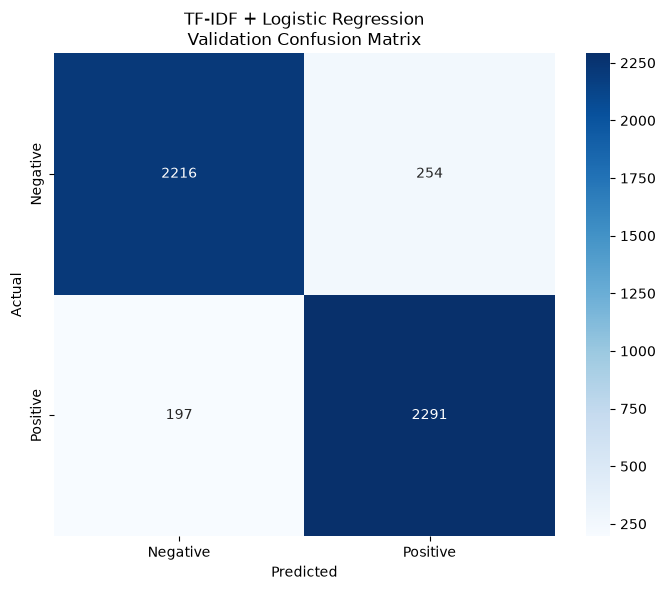

In [20]:
# confusion matrix
cm = confusion_matrix(y_val, y_val_pred_tfidf)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.title("TF-IDF + Logistic Regression\nValidation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("../images/tfidf_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# test results

y_test_pred_tfidf = tfidf_model.predict(X_test_tfidf)
y_test_prob_tfidf = tfidf_model.predict_proba(X_test_tfidf)[:, 1]
tfidf_test_accuracy = accuracy_score(y_test, y_test_pred_tfidf)
tfidf_test_precision = precision_score(y_test, y_test_pred_tfidf)
tfidf_test_recall = recall_score(y_test, y_test_pred_tfidf)
tfidf_test_f1 = f1_score( y_test, y_test_pred_tfidf)
tfidf_test_roc_auc = roc_auc_score(y_test, y_test_prob_tfidf)

print(f"Accuracy : {tfidf_test_accuracy:.4f}")
print(f"Precision: {tfidf_test_precision:.4f}")
print(f"Recall   : {tfidf_test_recall:.4f}")
print(f"F1 Score : {tfidf_test_f1:.4f}")
print(f"ROC-AUC  : {tfidf_test_roc_auc:.4f}")

Accuracy : 0.9091
Precision: 0.8996
Recall   : 0.9217
F1 Score : 0.9105
ROC-AUC  : 0.9697


In [22]:
# Word Embeddings

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, GlobalAveragePooling1D, Dense)

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense
)

VOCAB_SIZE = 30000
EMBEDDING_DIM = 128
MAX_SEQUENCE_LENGTH = 500

embedding_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        name="trainable_embedding"
    ),
    GlobalAveragePooling1D(),
    Dense(
        1,
        activation="sigmoid"
    )
])

embedding_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

embedding_model.build(
    input_shape=(None, MAX_SEQUENCE_LENGTH)
)

embedding_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape    ┃  Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ trainable_embedding   │ (None, 500,     │ 3,840,0… │
│ (Embedding)           │ 128)            │          │
├───────────────────────┼─────────────────┼──────────┤
│ global_average_pooli… │ (None, 128)     │        0 │
│ (GlobalAveragePoolin… │                 │          │
├───────────────────────┼─────────────────┼──────────┤
│ dense_1 (Dense)       │ (None, 1)       │      129 │
└───────────────────────┴─────────────────┴──────────┘

 Total params: 3,840,129 (14.65 MB)

 Trainable params: 3,840,129 (14.65 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
embedding_weights = (
    embedding_model
    .get_layer("trainable_embedding")
    .get_weights()[0]
)

print("Embedding matrix shape:", embedding_weights.shape)

Embedding matrix shape: (30000, 128)


In [31]:
phase3_results = pd.DataFrame({
    "Representation": [
        "Tokenization + Integer Encoding",
        "TF-IDF",
        "Word Embedding",
        "Trainable Embedding Layer"
    ],
    "Type": [
        "Integer Sequences",
        "Sparse Vector",
        "Dense Vector",
        "Learned Dense Vector"
    ],
    "Vocabulary Size": [
        30000,
        50000,
        30000,
        30000
    ],
    "Dimension / Length": [
        500,
        50000,
        128,
        128
    ],
    "Used For": [
        "RNN / LSTM / GRU",
        "Traditional ML Baseline",
        "Semantic Representation",
        "Deep Learning"
    ]
})

phase3_results

,Representation,Type,Vocabulary Size,Dimension / Length,Used For
0,Tokenization + Integer Encoding,Integer Sequences,30000,500,RNN / LSTM / GRU
1,TF-IDF,Sparse Vector,50000,50000,Traditional ML Baseline
2,Word Embedding,Dense Vector,30000,128,Semantic Representation
3,Trainable Embedding Layer,Learned Dense Vector,30000,128,Deep Learning


In [32]:
phase3_results.to_csv("../models/phase3_representation_summary.csv", index=False)
print("saved")

saved


In [33]:
tfidf_results = pd.DataFrame([{
    "Model": "TF-IDF + Logistic Regression",
    "Accuracy": tfidf_test_accuracy,
    "Precision": tfidf_test_precision,
    "Recall": tfidf_test_recall,
    "F1": tfidf_test_f1,
    "ROC_AUC": tfidf_test_roc_auc
}])

tfidf_results.to_csv(
    "../models/tfidf_baseline_results.csv",
    index=False
)

print("TF-IDF baseline results saved successfully.")

TF-IDF baseline results saved successfully.
